<a href="https://colab.research.google.com/github/Abhaykr45/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked actions + reason codes

The model output is used to create a ranked review queue rather than an automatic content-refresh decision.

Items are prioritized using the model's observed prediction signal and supporting content/performance features. Each recommendation includes a reason code so that a human reviewer can understand why the item was prioritized.

The queue is intended for decision-support. A human should review the underlying content and supporting signals before taking action.

In [6]:
!git clone https://github.com/Abhaykr45/flyrank-ml-internship.git

import pandas as pd

df = pd.read_csv("flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

In [8]:
df = pd.read_csv(
    "flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (30000, 44)


In [9]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]

target = "trend_direction"
group_column = "client_id"

data = df[
    features + [target, group_column]
].dropna().copy()

X = data[features]
y = data[target]
groups = data[group_column]

print("Rows used:", len(data))
print("Features:", features)
print("Target:", target)
print("Unique clients:", groups.nunique())

Rows used: 20018
Features: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position']
Target: trend_direction
Unique clients: 29


In [10]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training clients:", train_groups.nunique())
print("Testing clients:", test_groups.nunique())

Training rows: 14242
Testing rows: 5776
Training clients: 23
Testing clients: 6


In [11]:
train_clients = set(train_groups)
test_clients = set(test_groups)

overlap = train_clients.intersection(test_clients)

print("Client overlap:", len(overlap))

Client overlap: 0


In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest trained on training clients only.")

Random Forest trained on training clients only.


In [13]:
test_predictions = model.predict(X_test)

test_probabilities = model.predict_proba(X_test)

prediction_probability = test_probabilities.max(axis=1)

print("Predictions generated:", len(test_predictions))
print("Prediction probability range:",
      prediction_probability.min(),
      "to",
      prediction_probability.max())

Predictions generated: 5776
Prediction probability range: 0.24 to 0.99


In [14]:
queue = X_test.copy()

queue["predicted_trend"] = test_predictions
queue["prediction_probability"] = prediction_probability

queue = queue.reset_index(drop=True)

print("Queue rows:", len(queue))

queue.head()

Queue rows: 5776


,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update,ctr,avg_position,predicted_trend,prediction_probability
0,10.0,0.67,2.05,3221.0,20457.0,187,20,0.76,10.6,down,0.45
1,90.0,0.01,0.05,2481.0,15562.0,445,25,0.05,20.3,up,0.43
2,0.0,0.00,0.00,3515.0,23643.0,141,20,0.09,36.5,down,0.82
3,720.0,1.00,1.05,3080.0,18178.0,147,20,0.03,8.5,down,0.54
4,30.0,1.00,1.57,2673.0,16168.0,187,20,2.02,6.9,stable,0.33


In [15]:
ctr_median = X_train["ctr"].median()
position_median = X_train["avg_position"].median()

print("Training CTR median:", ctr_median)
print("Training average-position median:", position_median)

Training CTR median: 0.09
Training average-position median: 13.0


In [16]:
def get_reason_code(row):
    reasons = []

    if row["content_age_days"] >= 365:
        reasons.append("HIGH_CONTENT_AGE")

    if row["days_since_last_update"] >= 180:
        reasons.append("LONG_SINCE_UPDATE")

    if row["ctr"] < ctr_median:
        reasons.append("LOW_CTR")

    if row["avg_position"] > position_median:
        reasons.append("WEAKER_POSITION")

    if not reasons:
        reasons.append("MODERATE_SIGNAL")

    return "|".join(reasons)


queue["reason_code"] = queue.apply(
    get_reason_code,
    axis=1
)

queue[
    [
        "predicted_trend",
        "prediction_probability",
        "reason_code"
    ]
].head(10)

,predicted_trend,prediction_probability,reason_code
0,down,0.45,MODERATE_SIGNAL
1,up,0.43,HIGH_CONTENT_AGE|LOW_CTR|WEAKER_POSITION
2,down,0.82,WEAKER_POSITION
3,down,0.54,LOW_CTR
4,stable,0.33,MODERATE_SIGNAL
5,down,0.64,MODERATE_SIGNAL
6,down,0.44,MODERATE_SIGNAL
7,down,0.60,LOW_CTR
8,down,0.83,WEAKER_POSITION
9,down,0.65,LOW_CTR


In [17]:
def get_action(row):

    if (
        row["content_age_days"] >= 365
        and row["days_since_last_update"] >= 180
    ):
        return "PRIORITY_REVIEW"

    elif (
        row["ctr"] < ctr_median
        or row["avg_position"] > position_median
    ):
        return "PERFORMANCE_REVIEW"

    else:
        return "MONITOR"


queue["recommended_action"] = queue.apply(
    get_action,
    axis=1
)

In [18]:
queue = queue.sort_values(
    by="prediction_probability",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(
    1,
    len(queue) + 1
)

In [19]:
ranked_queue = queue[
    [
        "rank",
        "recommended_action",
        "reason_code",
        "predicted_trend",
        "prediction_probability",
        "content_age_days",
        "days_since_last_update",
        "ctr",
        "avg_position"
    ]
].copy()

ranked_queue.head(20)

,rank,recommended_action,reason_code,predicted_trend,prediction_probability,content_age_days,days_since_last_update,ctr,avg_position
0,1,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,138,20,0.00,0.0
1,2,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,126,20,0.00,0.0
2,3,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
3,4,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,169,20,0.00,0.1
4,5,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
5,6,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
6,7,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
7,8,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,131,20,0.00,0.0
8,9,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,141,20,0.00,0.0
9,10,PERFORMANCE_REVIEW,WEAKER_POSITION,down,0.97,300,104,0.13,42.5


In [20]:
action_counts = (
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="count")
)

action_counts

,recommended_action,count
0,PERFORMANCE_REVIEW,3828
1,MONITOR,1948


In [21]:
reason_counts = (
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_counts.head(20)

,reason_code,count
0,LOW_CTR,1729
1,MODERATE_SIGNAL,1425
2,LOW_CTR|WEAKER_POSITION,787
3,WEAKER_POSITION,730
4,HIGH_CONTENT_AGE,517
5,HIGH_CONTENT_AGE|WEAKER_POSITION,252
6,HIGH_CONTENT_AGE|LOW_CTR|WEAKER_POSITION,184
7,HIGH_CONTENT_AGE|LOW_CTR,93
8,LONG_SINCE_UPDATE|LOW_CTR,28
9,LONG_SINCE_UPDATE|LOW_CTR|WEAKER_POSITION,14


In [22]:
print("Top 20 content-review actions:")

ranked_queue.head(20)

Top 20 content-review actions:


,rank,recommended_action,reason_code,predicted_trend,prediction_probability,content_age_days,days_since_last_update,ctr,avg_position
0,1,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,138,20,0.00,0.0
1,2,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,126,20,0.00,0.0
2,3,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
3,4,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,169,20,0.00,0.1
4,5,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
5,6,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
6,7,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
7,8,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,131,20,0.00,0.0
8,9,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,141,20,0.00,0.0
9,10,PERFORMANCE_REVIEW,WEAKER_POSITION,down,0.97,300,104,0.13,42.5


### Interpretation

The ranked queue is generated from predictions on a client-grouped holdout set, so the model did not train on the clients represented in this queue.

The queue is intended to prioritize human review rather than automatically determine which content should be refreshed.

Reason codes provide interpretable signals associated with each recommendation. `PRIORITY_REVIEW` indicates that an item should be examined first based on the defined rules, while `PERFORMANCE_REVIEW` indicates that performance-related signals warrant additional review. `MONITOR` indicates that the available signals do not currently justify higher review priority.

The prediction probability is treated as a model output, not as a guarantee that the recommendation is correct.

The results should therefore be used as directional decision-support and reviewed by a person before any content action is taken.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended use and limits
### Intended use

This action playbook is intended to help content or SEO reviewers prioritize which content items should be reviewed first.

The ranked queue combines the model's observed prediction output with simple content and performance signals such as content age, time since the last update, CTR, and average position.

The output is intended as directional decision-support. It helps a reviewer focus attention on potentially higher-priority items, but it does not determine whether content should actually be changed.

### Intended users

The playbook is intended for human reviewers such as content, SEO, or editorial teams.

A reviewer should inspect the underlying content and supporting performance context before taking any action.

### Limits

The results are based on the available anonymized dataset and the evaluated validation design.

Week-6 validation showed an observed accuracy of 0.632368 under the original random split and 0.583968 under the client-grouped split. The lower grouped result indicates that performance may not generalize equally to unseen clients.

The model should therefore not be interpreted as a guaranteed predictor of future content performance.

The action queue is also dependent on the quality and timing of its input features. In particular, the timing of CTR and average-position measurements should be confirmed because these features were identified as potential timing risks during the Week-6 leakage audit.

The playbook is not a production system and should be treated as a research prototype for decision-support.

### What the output does not mean

A high-ranked item does not mean that the content definitely needs a refresh.

A high prediction probability does not guarantee a correct prediction.

A reason code explains the observed signals used for prioritization; it does not establish causation.

The queue should not be used to automatically publish, delete, rewrite, or substantially change content without human review.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human review + the no-go list
### Human review rules

Every item in the ranked queue must be reviewed by a human before any content action is taken.

The reviewer should:

1. Check the current content and determine whether the page actually needs improvement.
2. Verify that the observed performance signals are still relevant and recent.
3. Check whether the content is aligned with the intended search intent and topic.
4. Review the reason code and determine whether it provides a reasonable explanation for the recommendation.
5. Consider business, editorial, legal, or brand requirements that are not represented in the model features.
6. Decide whether to refresh, monitor, leave unchanged, or investigate the item further.
7. Record the final human decision when the playbook is used for evaluation.

### Human decision options

The reviewer should be able to choose among:

- `REFRESH` — evidence supports updating the content.
- `MONITOR` — signals are not strong enough for immediate action.
- `NO_CHANGE` — review found no useful reason to modify the content.
- `INVESTIGATE` — additional information is needed before deciding.
- `ESCALATE` — the item requires specialist or policy review.

### No-go list

The following decisions should not be automated using this model:

- Automatically publishing or modifying content.
- Automatically deleting or unpublishing content.
- Automatically changing factual, medical, financial, legal, or safety-sensitive information.
- Automatically changing titles, claims, or recommendations without human review.
- Automatically prioritizing content based only on the model score.
- Treating prediction probability as certainty.
- Making decisions about individual clients or organizations from the model output.
- Using the queue as a production control system.

### Why human review is required

The model uses a limited set of structured features and cannot observe every factor that affects whether content should be changed.

The Week-6 validation audit also showed lower measured accuracy under the client-grouped split than under the original random split. This indicates that performance can change when the evaluation setting becomes more demanding.

Therefore, the ranked queue should be treated as directional decision-support. Human review remains necessary before taking content action.

### Reviewer checklist

Before taking action, confirm:

- [ ] The item has been reviewed by a person.
- [ ] The reason code matches the available evidence.
- [ ] The performance data is sufficiently recent.
- [ ] The content still matches the intended topic/search intent.
- [ ] No important business, editorial, legal, or safety constraint is being ignored.
- [ ] The final action is documented.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / retrain triggers
### Monitoring signals

The playbook should be periodically reviewed for changes in the data and recommendation quality.

The main signals to monitor are:

1. **Prediction performance** — measure accuracy or another appropriate validation metric when new labeled outcomes become available.
2. **Feature distribution** — check whether important input features such as search volume, CTR, average position, and content age have changed substantially.
3. **Action distribution** — monitor whether the queue becomes dominated by one recommendation such as `PRIORITY_REVIEW` or `PERFORMANCE_REVIEW`.
4. **Reason-code distribution** — check whether the reasons driving recommendations change substantially over time.
5. **Human-review outcomes** — compare model recommendations with the decisions made by human reviewers.
6. **Data quality** — monitor missing values, unexpected ranges, and changes in feature availability.
### Retrain and re-evaluation triggers

The model should not be retrained simply on a fixed schedule without checking evidence.

Re-evaluation should be considered when:

- Measured validation performance decreases meaningfully on newly available labeled data.
- The distribution of important features changes substantially.
- The distribution of `trend_direction` changes substantially.
- Human reviewers frequently disagree with the recommended action.
- New content or client groups differ materially from the data used for validation.
- Important features change definition, measurement window, or availability.
- A possible leakage or data-quality issue is discovered.

If one or more of these conditions occur, the model should be re-evaluated before its recommendations are used again.
### Proposed lightweight thresholds

For a practical research workflow, the following thresholds can be used as review triggers:

| Signal | Review trigger |
|---|---|
| Validation performance | Measured performance falls by ≥5 percentage points from the established reference |
| Missing feature values | Missingness increases noticeably from the training data |
| Action distribution | One action becomes unusually dominant |
| Reason-code distribution | Major change in the most common reason codes |
| Human disagreement | Repeated disagreement between reviewers and recommendations |
| Feature distribution | Clear shift in important input distributions |
| Target distribution | Noticeable change in `trend_direction` proportions |

These are proposed monitoring triggers for the research workflow, not validated production thresholds. They should be adjusted after observing additional data.
### Monitoring interpretation

The purpose of monitoring is to identify when the current playbook may no longer represent the data on which it was evaluated.

A trigger does not automatically mean that the model must be retrained. It means that the model and validation design should be reviewed.

Retraining should only occur after checking data quality, feature timing, target definition, and validation performance. The updated model should then be evaluated using an appropriate grouped or time-aware validation design before being used for decision-support again.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the paper

The notebook exports the ranked action queue and summary information so that the results can be reused in the research paper.

The queue is regenerated by the notebook rather than manually edited. Client identifiers and other unnecessary identifying fields are excluded from the exported queue.

In [23]:
!git clone https://github.com/Abhaykr45/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [24]:
import os

output_dir = "flyrank-ml-internship/work/outputs"
figure_dir = "flyrank-ml-internship/work/figures"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)

print("Output directory ready:", output_dir)
print("Figure directory ready:", figure_dir)

Output directory ready: flyrank-ml-internship/work/outputs
Figure directory ready: flyrank-ml-internship/work/figures


In [25]:
queue_path = os.path.join(
    output_dir,
    "ranked_action_queue.csv"
)

ranked_queue.to_csv(
    queue_path,
    index=False
)

print("Ranked queue exported to:")
print(queue_path)

Ranked queue exported to:
flyrank-ml-internship/work/outputs/ranked_action_queue.csv


In [26]:
check_queue = pd.read_csv(queue_path)

print("Exported rows:", len(check_queue))
print("Exported columns:")
print(check_queue.columns.tolist())

check_queue.head(10)

Exported rows: 5776
Exported columns:
['rank', 'recommended_action', 'reason_code', 'predicted_trend', 'prediction_probability', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position']


,rank,recommended_action,reason_code,predicted_trend,prediction_probability,content_age_days,days_since_last_update,ctr,avg_position
0,1,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,138,20,0.00,0.0
1,2,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,126,20,0.00,0.0
2,3,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
3,4,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,169,20,0.00,0.1
4,5,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
5,6,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
6,7,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
7,8,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,131,20,0.00,0.0
8,9,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,141,20,0.00,0.0
9,10,PERFORMANCE_REVIEW,WEAKER_POSITION,down,0.97,300,104,0.13,42.5


In [27]:
action_summary = (
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="count")
)

action_summary

,recommended_action,count
0,PERFORMANCE_REVIEW,3828
1,MONITOR,1948


In [28]:
summary_path = os.path.join(
    output_dir,
    "action_summary.csv"
)

action_summary.to_csv(
    summary_path,
    index=False
)

print("Action summary exported to:")
print(summary_path)

Action summary exported to:
flyrank-ml-internship/work/outputs/action_summary.csv


In [29]:
reason_summary = (
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_summary.head(20)

,reason_code,count
0,LOW_CTR,1729
1,MODERATE_SIGNAL,1425
2,LOW_CTR|WEAKER_POSITION,787
3,WEAKER_POSITION,730
4,HIGH_CONTENT_AGE,517
5,HIGH_CONTENT_AGE|WEAKER_POSITION,252
6,HIGH_CONTENT_AGE|LOW_CTR|WEAKER_POSITION,184
7,HIGH_CONTENT_AGE|LOW_CTR,93
8,LONG_SINCE_UPDATE|LOW_CTR,28
9,LONG_SINCE_UPDATE|LOW_CTR|WEAKER_POSITION,14


In [30]:
reason_path = os.path.join(
    output_dir,
    "reason_code_summary.csv"
)

reason_summary.to_csv(
    reason_path,
    index=False
)

print("Reason-code summary exported to:")
print(reason_path)

Reason-code summary exported to:
flyrank-ml-internship/work/outputs/reason_code_summary.csv


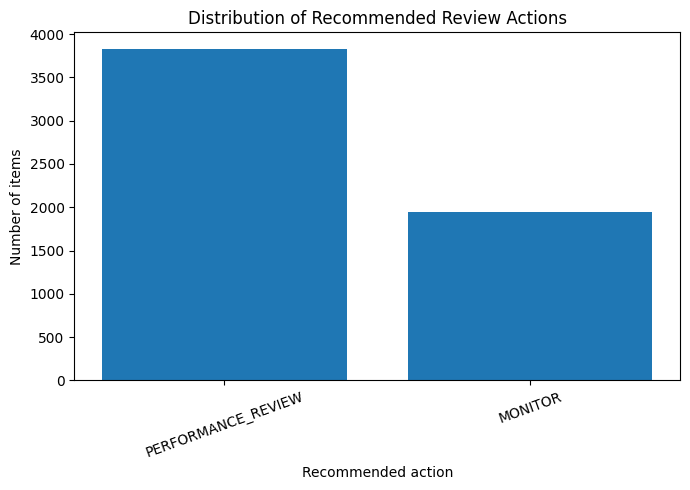

Figure saved to:
flyrank-ml-internship/work/figures/action_distribution.png


In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    action_summary["recommended_action"],
    action_summary["count"]
)

plt.xlabel("Recommended action")
plt.ylabel("Number of items")
plt.title("Distribution of Recommended Review Actions")

plt.xticks(rotation=20)
plt.tight_layout()

figure_path = os.path.join(
    figure_dir,
    "action_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [32]:
print("=== Week-7 exports ===")

print("\nOutput files:")

for file in [
    queue_path,
    summary_path,
    reason_path
]:
    print(os.path.exists(file), file)

print("\nFigure:")
print(os.path.exists(figure_path), figure_path)

=== Week-7 exports ===

Output files:
True flyrank-ml-internship/work/outputs/ranked_action_queue.csv
True flyrank-ml-internship/work/outputs/action_summary.csv
True flyrank-ml-internship/work/outputs/reason_code_summary.csv

Figure:
True flyrank-ml-internship/work/figures/action_distribution.png


### Export interpretation

The ranked action queue is generated directly from the notebook and exported as a CSV for reuse in the research paper.

The queue contains review priorities, reason codes, model prediction outputs, and supporting signals. Client identifiers are excluded from the export.

The action and reason-code summaries provide compact evidence that can be reused when describing the playbook.

The exported figure shows the observed distribution of recommended review actions. These outputs are intended for research and decision-support, not as production control artifacts.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.